# K-Nearest Neighbors and Naive Bayes

This notebook introduces two classic classification algorithms with the Breast Cancer Wisconsin Diagnostic dataset from `scikit-learn`.

Dataset: Breast Cancer Wisconsin Diagnostic dataset. We predict whether a tumor is **malignant** (`1`) or **benign** (`0`).

We will cover:

- how K-Nearest Neighbors makes predictions from nearby training examples;
- why feature scaling is essential for distance-based models;
- how to choose `k` with cross-validation;
- how Gaussian Naive Bayes models each feature within each class;
- how to compare both models with the same train/test split.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 4)

plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "figure.figsize": (8, 4.5),
})

## 1. Load the Breast Cancer Dataset

`load_breast_cancer` is bundled with `scikit-learn`, so the notebook does not need external data files.

The original target uses `0 = malignant` and `1 = benign`. For consistency with earlier classification notebooks, we recode it so that:

- `1` means **malignant**, the positive class;
- `0` means **benign**.

In [2]:
cancer = load_breast_cancer(as_frame=True)
raw_df: pd.DataFrame = cancer.frame.copy()

X = raw_df.drop(columns="target")
y = (raw_df["target"] == 0).astype(int)

label_names = {0: "benign", 1: "malignant"}
display_labels = [label_names[0], label_names[1]]

preview_df = X.copy()
preview_df["diagnosis"] = y.map(label_names)

class_balance = pd.DataFrame({
    "label": pd.Series(label_names),
    "count": y.value_counts().sort_index(),
    "share": y.value_counts(normalize=True).sort_index(),
})

print(f"Rows: {len(raw_df)}")
print(f"Features: {X.shape[1]}")
print(f"Original sklearn target names: {list(cancer.target_names)}")

display(class_balance)
preview_df.head()

Rows: 569
Features: 30
Original sklearn target names: ['malignant', 'benign']


,label,count,share
0,benign,357,0.6274
1,malignant,212,0.3726


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,malignant
1,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,malignant
2,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,malignant
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,malignant
4,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,malignant


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "malignant_share": [y_train.mean(), y_test.mean()],
}, index=["train", "test"])

split_summary

,rows,malignant_share
train,426,0.3732
test,143,0.3706


In [4]:
def evaluate_classifier(name, model, X_test, y_test):
    """Return the main binary classification metrics for a fitted classifier."""
    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test)[:, 1]

    return {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_score),
    }


def show_report(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    print(name)
    print(classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=display_labels,
    ))

## 2. K-Nearest Neighbors: The Basic Idea

K-Nearest Neighbors, or **KNN**, predicts a new example by looking at the `k` closest examples in the training set.

For numeric features, a common distance is Euclidean distance:

$$distance(a, b) = \sqrt{(a_1-b_1)^2 + (a_2-b_2)^2 + \dots + (a_n-b_n)^2}$$

For classification, the predicted class is usually the majority class among the nearest neighbors.

In [5]:
two_features = ["mean radius", "mean texture"]
sample_idx = X_test.index[0]

sample = X_test.loc[[sample_idx], two_features].copy()
sample["actual_diagnosis"] = label_names[y_test.loc[sample_idx]]

raw_distances = (
    ((X_train[two_features] - X_test.loc[sample_idx, two_features]) ** 2)
    .sum(axis=1)
    .pow(0.5)
    .sort_values()
)

nearest_neighbors = X_train.loc[raw_distances.head(7).index, two_features].copy()
nearest_neighbors["diagnosis"] = y_train.loc[nearest_neighbors.index].map(label_names)
nearest_neighbors["distance_to_test_point"] = raw_distances.head(7).values

display(sample)
nearest_neighbors

,mean radius,mean texture,actual_diagnosis
12,19.17,24.8,malignant


,mean radius,mean texture,diagnosis,distance_to_test_point
42,19.07,24.81,malignant,0.1005
87,19.02,24.59,malignant,0.2581
30,18.63,25.11,malignant,0.6227
129,19.79,25.12,malignant,0.6977
274,17.93,24.48,malignant,1.2806
78,20.18,23.97,malignant,1.3073
302,20.09,23.86,malignant,1.3153


## 3. Train a KNN Classifier

KNN is distance-based, so feature scale matters. A feature measured in large units can dominate the distance calculation.

We wrap `StandardScaler` and `KNeighborsClassifier` in one pipeline so the scaler is fit only on the training data.

In [6]:
knn_5 = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5),
)

knn_5.fit(X_train, y_train)

knn_5_metrics = evaluate_classifier("KNN, k=5, scaled", knn_5, X_test, y_test)
pd.DataFrame([knn_5_metrics]).set_index("model").round(3)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
"KNN, k=5, scaled",0.958,0.98,0.906,0.941,0.986


KNN, k=5, scaled
              precision    recall  f1-score   support

      benign       0.95      0.99      0.97        90
   malignant       0.98      0.91      0.94        53

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



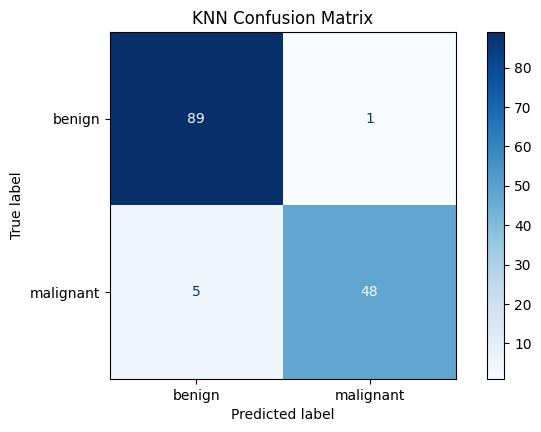

In [7]:
show_report("KNN, k=5, scaled", knn_5, X_test, y_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_5.predict(X_test),
    display_labels=display_labels,
    cmap="Blues",
)
plt.title("KNN Confusion Matrix")
plt.grid(False)
plt.show()

## 4. Why Scaling Matters for KNN

The breast cancer dataset contains features on very different numeric scales. For example, area features are much larger than smoothness features.

The model below compares KNN with raw features against KNN with standardized features.

In [8]:
feature_ranges = pd.DataFrame({
    "min": X_train.min(),
    "max": X_train.max(),
    "range": X_train.max() - X_train.min(),
}).sort_values("range", ascending=False)

feature_ranges.head(10)

,min,max,range
worst area,185.200,4254.00,4068.800
mean area,143.500,2501.00,2357.500
area error,6.802,542.20,535.398
worst perimeter,50.410,251.20,200.790
mean perimeter,43.790,188.50,144.710
worst texture,12.020,49.54,37.520
mean texture,9.710,39.28,29.570
worst radius,7.930,36.04,28.110
perimeter error,0.757,21.98,21.223
mean radius,6.981,28.11,21.129


In [9]:
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)

scaling_comparison = pd.DataFrame([
    evaluate_classifier("KNN, k=5, raw features", knn_raw, X_test, y_test),
    evaluate_classifier("KNN, k=5, scaled features", knn_5, X_test, y_test),
]).set_index("model")

scaling_comparison.round(3)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
"KNN, k=5, raw features",0.923,0.977,0.811,0.887,0.956
"KNN, k=5, scaled features",0.958,0.980,0.906,0.941,0.986


## 5. Choose `k` with Cross-Validation

The value of `k` controls the smoothness of KNN predictions.

- Small `k`: more flexible, but more sensitive to noise.
- Large `k`: smoother, but can miss local patterns.

We choose `k` using only the training set, then evaluate the selected model once on the test set.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
k_values = range(1, 32, 2)

cv_rows = []
for k in k_values:
    candidate = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k),
    )
    scores = cross_validate(
        candidate,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1"],
    )
    cv_rows.append({
        "k": k,
        "cv_accuracy": scores["test_accuracy"].mean(),
        "cv_precision": scores["test_precision"].mean(),
        "cv_recall": scores["test_recall"].mean(),
        "cv_f1": scores["test_f1"].mean(),
    })

knn_cv_results = pd.DataFrame(cv_rows)
best_k = int(knn_cv_results.sort_values("cv_f1", ascending=False).iloc[0]["k"])

print(f"Best k by cross-validated F1: {best_k}")
knn_cv_results.sort_values("cv_f1", ascending=False).head(8).round(3)

Best k by cross-validated F1: 3


,k,cv_accuracy,cv_precision,cv_recall,cv_f1
1,3,0.965,0.987,0.918,0.951
3,7,0.958,0.986,0.900,0.941
2,5,0.958,0.986,0.899,0.941
0,1,0.953,0.956,0.918,0.936
4,9,0.953,0.986,0.887,0.933
5,11,0.953,0.986,0.887,0.933
7,15,0.948,0.985,0.875,0.926
8,17,0.948,0.985,0.875,0.926


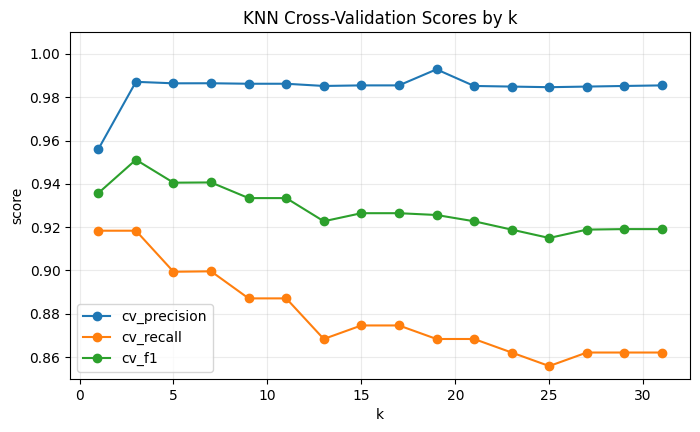

In [11]:
ax = knn_cv_results.plot(
    x="k",
    y=["cv_precision", "cv_recall", "cv_f1"],
    marker="o",
)
ax.set_title("KNN Cross-Validation Scores by k")
ax.set_ylabel("score")
ax.set_ylim(0.85, 1.01)
plt.show()

In [12]:
knn_tuned = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=best_k),
)

knn_tuned.fit(X_train, y_train)

knn_tuned_metrics = evaluate_classifier(
    f"KNN, k={best_k}, scaled",
    knn_tuned,
    X_test,
    y_test,
)

pd.DataFrame([knn_tuned_metrics]).set_index("model").round(3)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
"KNN, k=3, scaled",0.958,1.0,0.887,0.94,0.988


## 6. Visualize KNN on Two Features

The real model uses all features. A two-feature model is easier to visualize and helps show the local, neighbor-based shape of KNN decision regions.

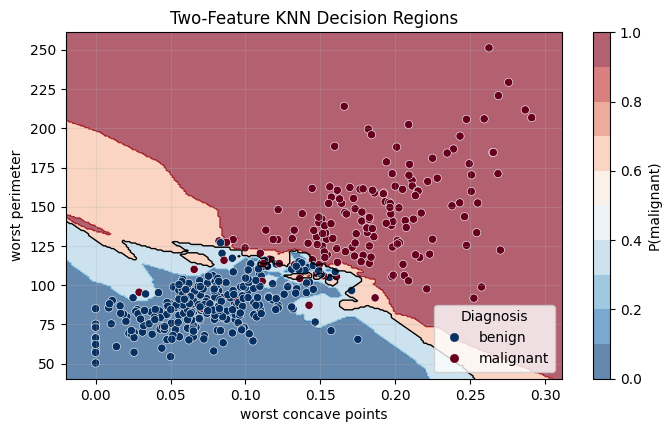

In [13]:
plot_features = ["worst concave points", "worst perimeter"]

knn_2d = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=best_k),
)
knn_2d.fit(X_train[plot_features], y_train)

x_min, x_max = X_train[plot_features[0]].min() - 0.02, X_train[plot_features[0]].max() + 0.02
y_min, y_max = X_train[plot_features[1]].min() - 10, X_train[plot_features[1]].max() + 10

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 250),
    np.linspace(y_min, y_max, 250),
)
grid = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=plot_features)
malignant_probability = knn_2d.predict_proba(grid)[:, 1].reshape(xx.shape)

plt.contourf(
    xx,
    yy,
    malignant_probability,
    levels=np.linspace(0, 1, 11),
    cmap="RdBu_r",
    alpha=0.65,
)
plt.colorbar(label="P(malignant)")
plt.contour(xx, yy, malignant_probability, levels=[0.5], colors="black", linewidths=1)

scatter = plt.scatter(
    X_train[plot_features[0]],
    X_train[plot_features[1]],
    c=y_train,
    cmap="RdBu_r",
    edgecolor="white",
    linewidth=0.4,
    s=35,
)
plt.legend(
    handles=scatter.legend_elements()[0],
    labels=display_labels,
    title="Diagnosis",
    loc="lower right",
)
plt.xlabel(plot_features[0])
plt.ylabel(plot_features[1])
plt.title("Two-Feature KNN Decision Regions")
plt.show()

## 7. Naive Bayes: The Basic Idea

Naive Bayes uses Bayes' theorem to estimate the class probability:

$$P(class \mid features) \propto P(class) \times P(features \mid class)$$

It is called **naive** because it assumes the features are conditionally independent within each class.

The breast cancer features are continuous numeric measurements, so we use `GaussianNB`. It models each feature within each class with a normal distribution.

In [14]:
gaussian_nb = GaussianNB()
gaussian_nb.fit(X_train, y_train)

nb_metrics = evaluate_classifier("Gaussian Naive Bayes", gaussian_nb, X_test, y_test)
pd.DataFrame([nb_metrics]).set_index("model").round(3)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Gaussian Naive Bayes,0.944,1.0,0.849,0.918,0.995


Gaussian Naive Bayes
              precision    recall  f1-score   support

      benign       0.92      1.00      0.96        90
   malignant       1.00      0.85      0.92        53

    accuracy                           0.94       143
   macro avg       0.96      0.92      0.94       143
weighted avg       0.95      0.94      0.94       143



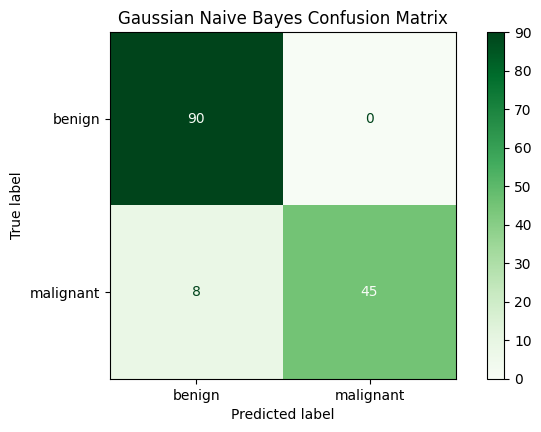

In [15]:
show_report("Gaussian Naive Bayes", gaussian_nb, X_test, y_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    gaussian_nb.predict(X_test),
    display_labels=display_labels,
    cmap="Greens",
)
plt.title("Gaussian Naive Bayes Confusion Matrix")
plt.grid(False)
plt.show()

## 8. Inspect What Gaussian Naive Bayes Learned

`GaussianNB` learns a mean and variance for every feature within every class. The table below ranks features by the absolute standardized gap between benign and malignant class means.

In [16]:
nb_feature_summary = pd.DataFrame({
    "feature": X_train.columns,
    "benign_mean": gaussian_nb.theta_[0],
    "malignant_mean": gaussian_nb.theta_[1],
    "benign_variance": gaussian_nb.var_[0],
    "malignant_variance": gaussian_nb.var_[1],
})

pooled_std = np.sqrt((nb_feature_summary["benign_variance"] + nb_feature_summary["malignant_variance"]) / 2)
nb_feature_summary["standardized_mean_gap"] = (
    (nb_feature_summary["malignant_mean"] - nb_feature_summary["benign_mean"]).abs()
    / pooled_std
)

class_priors = pd.Series(
    gaussian_nb.class_prior_,
    index=[label_names[int(class_id)] for class_id in gaussian_nb.classes_],
    name="class_prior",
)

display(class_priors.to_frame())
nb_feature_summary.sort_values("standardized_mean_gap", ascending=False).head(10)

,class_prior
benign,0.6268
malignant,0.3732


,feature,benign_mean,malignant_mean,benign_variance,malignant_variance,standardized_mean_gap
22,worst perimeter,87.2899,142.5108,189.1322,918.5338,2.3465
20,worst radius,13.4229,21.3084,4.0296,19.2153,2.3130
27,worst concave points,0.0755,0.1820,0.0017,0.0026,2.2867
2,mean perimeter,78.1804,115.7231,142.6911,503.3469,2.0889
0,mean radius,12.1655,17.5298,3.2379,10.8131,2.0238
23,worst area,563.2206,1446.6541,27817.2242,387348.2102,1.9390
7,mean concave points,0.0256,0.0881,0.0006,0.0016,1.8837
3,mean area,464.8577,987.8956,18574.9351,146517.0235,1.8205
6,mean concavity,0.0468,0.1592,0.0025,0.0064,1.6860
26,worst concavity,0.1723,0.4443,0.0228,0.0321,1.6418


## 9. Compare KNN and Naive Bayes

Both models are evaluated on the same held-out test set. Accuracy is useful, but for malignant tumor detection, recall and F1 are often more informative because missing a malignant case is costly.

In [17]:
model_comparison = pd.DataFrame([
    knn_5_metrics,
    knn_tuned_metrics,
    nb_metrics,
]).set_index("model")

model_comparison.sort_values("f1", ascending=False).round(3)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
"KNN, k=5, scaled",0.958,0.98,0.906,0.941,0.986
"KNN, k=3, scaled",0.958,1.00,0.887,0.940,0.988
Gaussian Naive Bayes,0.944,1.00,0.849,0.918,0.995


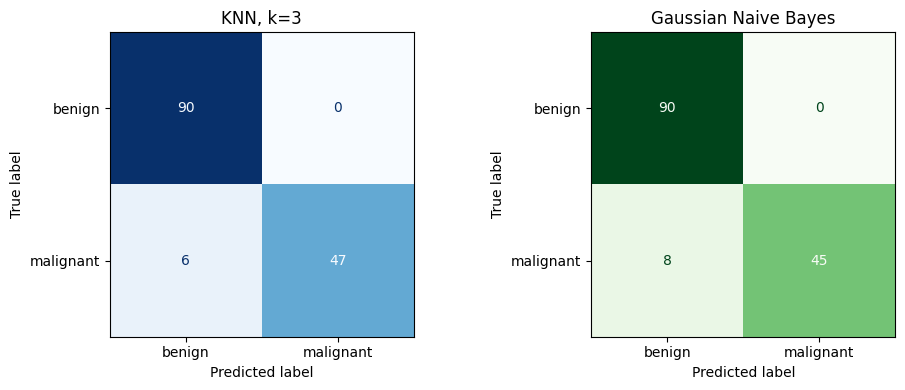

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_tuned.predict(X_test),
    display_labels=display_labels,
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(f"KNN, k={best_k}")
axes[0].grid(False)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    gaussian_nb.predict(X_test),
    display_labels=display_labels,
    cmap="Greens",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title("Gaussian Naive Bayes")
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 10. Compare Individual Predictions

The next table shows test examples where the tuned KNN model and Gaussian Naive Bayes disagree. Disagreements are useful cases to inspect because they reveal how model assumptions affect predictions.

In [19]:
prediction_comparison = pd.DataFrame({
    "actual": y_test.map(label_names),
    "knn_prediction": pd.Series(knn_tuned.predict(X_test), index=X_test.index).map(label_names),
    "nb_prediction": pd.Series(gaussian_nb.predict(X_test), index=X_test.index).map(label_names),
    "knn_probability_malignant": knn_tuned.predict_proba(X_test)[:, 1],
    "nb_probability_malignant": gaussian_nb.predict_proba(X_test)[:, 1],
})

prediction_comparison["models_disagree"] = (
    prediction_comparison["knn_prediction"] != prediction_comparison["nb_prediction"]
)

prediction_comparison.sort_values(
    ["models_disagree", "nb_probability_malignant"],
    ascending=[False, False],
).head(12)

,actual,knn_prediction,nb_prediction,knn_probability_malignant,nb_probability_malignant,models_disagree
277,malignant,benign,malignant,0.3333,1.0000,True
329,malignant,benign,malignant,0.3333,1.0000,True
39,malignant,malignant,benign,0.6667,0.2041,True
215,malignant,malignant,benign,0.6667,0.1963,True
86,malignant,malignant,benign,0.6667,0.0032,True
100,malignant,malignant,benign,0.6667,0.0022,True
12,malignant,malignant,malignant,1.0000,1.0000,False
321,malignant,malignant,malignant,1.0000,1.0000,False
218,malignant,malignant,malignant,1.0000,1.0000,False
562,malignant,malignant,malignant,1.0000,1.0000,False


## 11. Practical Takeaways

- **KNN** is simple and can learn nonlinear boundaries, but it needs scaled features and prediction can become slow on large training sets.
- **Small `k`** can overreact to noise; **large `k`** smooths predictions but may hide local structure.
- **Gaussian Naive Bayes** is fast and often works surprisingly well, especially as a baseline, but its independence and Gaussian assumptions are strong.
- For medical classification examples, do not rely on accuracy alone. Inspect recall, precision, F1, confusion matrices, and the cost of each error type.